In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [6]:

from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt
from model.linear_model import LinearModel
import os
import csv

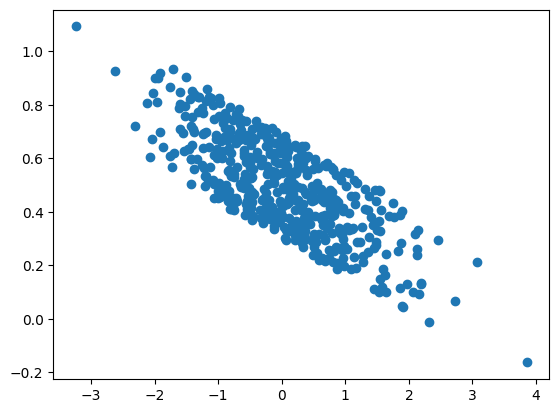

In [3]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [ ]:
def run_all_linear_regression(datasets, learning_rates, output_dir, summary_file='all_metrics.csv'):
    seed = 42
    np.random.seed(seed)


    summary_path = os.path.join(output_dir, summary_file)
    with open(summary_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)

        writer.writerow(['Dataset', 'Learning Rate', 'MSE', 'MAE', 'RMSE', 'R-squared'])


        for dataset_name in datasets:

            print(f"=======================================================")
            print(f"Using dataset: {dataset_name}")
            # Loading data
            data_path = f"data/linear_data/{dataset_name}.npz"
            loaded_data = np.load(data_path)


            X = loaded_data['X_data']
            y = loaded_data['y_data']
            W = loaded_data['W_data']

            # Show the size of data
            print(f"X size: {X.shape}, y size: {y.shape}")

            # Make sure size and dim correct.
            size = X.shape[0]
            dim = X.shape[1]-1
            print(f"Processing {dataset_name}: size={size}, dim={dim}")


            # Train the model
            for lr in learning_rates:
                print(f"Built model for {dataset_name} with learning rate = {lr}")

                seed = 42 # do not change the seed
                np.random.seed(seed)

                # Setting loss function and gradient. 
                loss_fn = MSE
                grad_fn = MSE_grad

                # Split dataset to train dataset and validation dataset
                X_train,y_train,X_val,y_val = get_train_val(X,y)

                # Setting model, starting training snd get the loss curve
                loss_curve_path = os.path.join(output_dir, f'{dataset_name}_lr{lr}_loss.png')
                model = LinearModel(dim,True,loss_fn,grad_fn)
                model.fit(X_train,y_train,lr=lr,n_iteration =500,val_ratio=0.2,save_path=loss_curve_path)


                # Get the Prediction
                y_val_pred = model.predict(X_val)


                # Evaluation 
                # Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
                metrics = evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')
                
                writer.writerow([dataset_name, lr, metrics['MSE'], metrics['MAE'], metrics['RMSE'], metrics['R-squared']])

                # Plot
                plt.figure()
                plt.scatter(X_val[:,1], y_val, label='True')
                plt.plot(X_val[:,1], y_val_pred, label='Predicted', color='red')
                plt.title(f'{dataset_name} | lr={lr} Predictions')
                plt.xlabel('X')
                plt.ylabel('y')
                plt.legend()
                pred_plot_file = os.path.join(output_dir, f'{dataset_name}_lr{lr}_prediction.png')
                plt.savefig(pred_plot_file)
                plt.close()



Using dataset: linear_data_A
X size: (1600, 2), y size: (1600,)
Processing linear_data_A: size=1600, dim=1
Built model for linear_data_A with learning rate = 0.1
50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


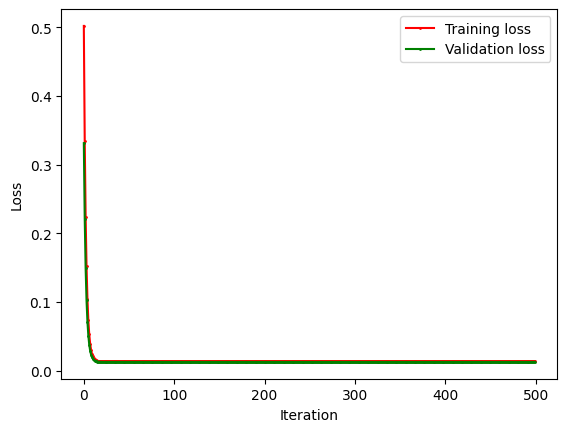

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
Built model for linear_data_A with learning rate = 0.01
50. Training loss: 0.08822499761459246, Val loss:0.08344253861678516
100. Training loss: 0.024461533163063473, Val loss:0.022730598385935285
150. Training loss: 0.015054341888577384, Val loss:0.013961184271627123
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002822
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964216, Val loss:0.012579546976647175
500. Training loss: 0.013423625043327498, Val loss:0.01257988125786218


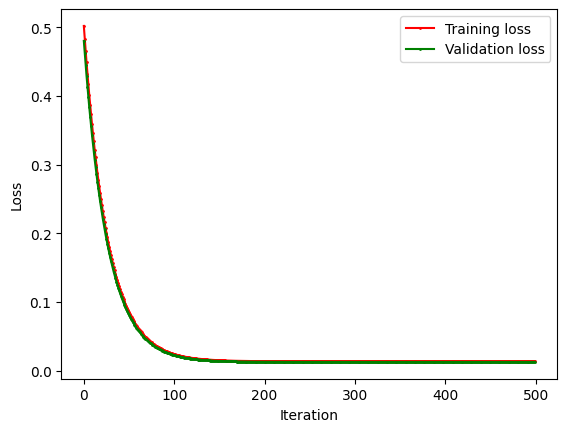

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
Built model for linear_data_A with learning rate = 0.001
50. Training loss: 0.418984925274338, Val loss:0.41420880497204005
100. Training loss: 0.34884281364937003, Val loss:0.3445251797643867
150. Training loss: 0.2908358402579774, Val loss:0.28691334687110626
200. Training loss: 0.2428637953466062, Val loss:0.23928338706190336
250. Training loss: 0.20319008395293756, Val loss:0.19990713434668128
300. Training loss: 0.17037874765339453, Val loss:0.16735555250253287
350. Training loss: 0.14324239869173933, Val loss:0.1404469551481651
400. Training loss: 0.12079917484937551, Val loss:0.11820419110090803
450. Training loss: 0.10223715148116824, Val loss:0.09981924222927965
500. Training loss: 0.08688491828078371, Val loss:0.08462395006505144


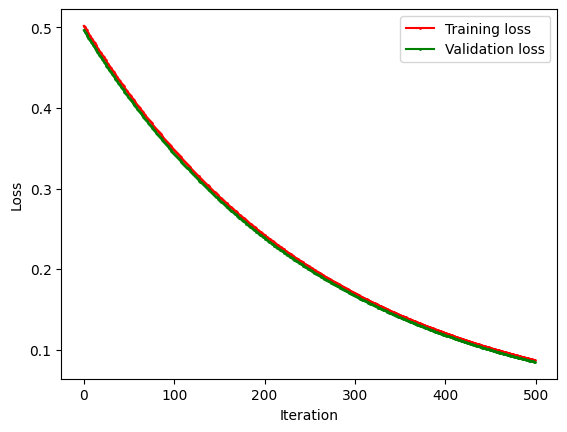

=== Linear Regression Evaluation ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836
Using dataset: linear_data_B
X size: (1600, 2), y size: (1600,)
Processing linear_data_B: size=1600, dim=1
Built model for linear_data_B with learning rate = 0.1
50. Training loss: 0.21477796029761928, Val loss:0.20128111574984853
100. Training loss: 0.21477795969579408, Val loss:0.20128143543301202
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080995
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


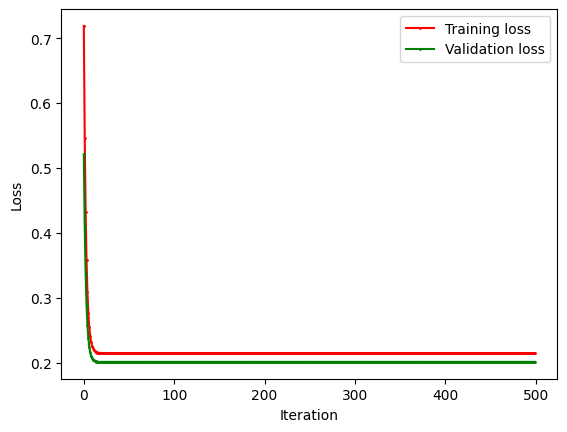

=== Linear Regression Evaluation ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
Built model for linear_data_B with learning rate = 0.01
50. Training loss: 0.2920213425997664, Val loss:0.2702611408646165
100. Training loss: 0.2261837940753283, Val loss:0.2101879308116208
150. Training loss: 0.2164640141651331, Val loss:0.2021155812609517
200. Training loss: 0.21502743867502366, Val loss:0.20122361991141446
250. Training loss: 0.21481490508468085, Val loss:0.20120482979710497
300. Training loss: 0.21478343493349927, Val loss:0.20124452118342356
350. Training loss: 0.21477877162933795, Val loss:0.20126634873684507
400. Training loss: 0.21477808016505961, Val loss:0.20127557772119783
450. Training loss: 0.21477797757871428, Val loss:0.20127920153421996
500. Training loss: 0.2147779623514954, Val loss:0.20128058874123028


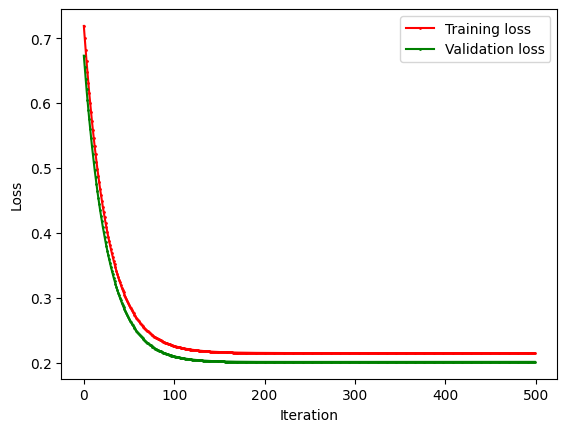

=== Linear Regression Evaluation ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
Built model for linear_data_B with learning rate = 0.001
50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370382
150. Training loss: 0.5011005997675119, Val loss:0.47616215994096633
200. Training loss: 0.4516056474010014, Val loss:0.4277683253433776
250. Training loss: 0.41066917554133203, Val loss:0.3878209660417229
300. Training loss: 0.37681081233745717, Val loss:0.354852342304647
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083346
450. Training loss: 0.30648453628529515, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


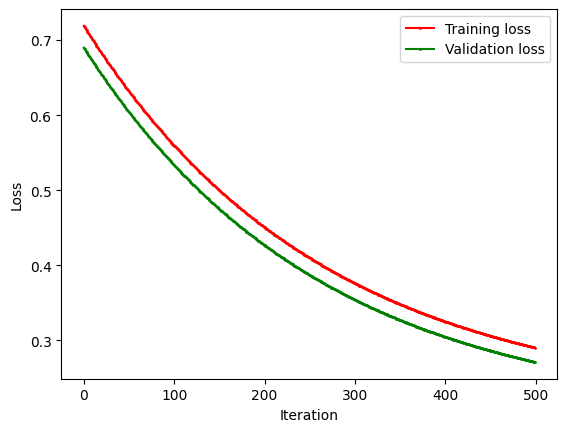

=== Linear Regression Evaluation ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011
Using dataset: linear_data_C
X size: (8000, 6), y size: (8000,)
Processing linear_data_C: size=8000, dim=5
Built model for linear_data_C with learning rate = 0.1
50. Training loss: 0.0131818971313023, Val loss:0.013771656751385359
100. Training loss: 0.013181896123422132, Val loss:0.013771595669720494
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


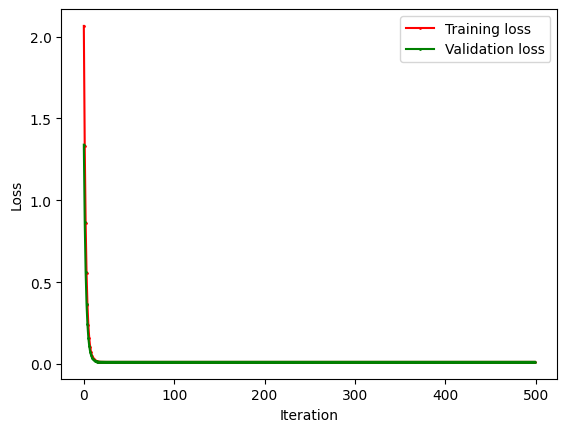

=== Linear Regression Evaluation ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
Built model for linear_data_C with learning rate = 0.01
50. Training loss: 0.3016776572102272, Val loss:0.2940364008397445
100. Training loss: 0.052301281914569585, Val loss:0.052286225702638675
150. Training loss: 0.018505850726527058, Val loss:0.019175412162323588
200. Training loss: 0.013908983721033275, Val loss:0.014564896297918123
250. Training loss: 0.013281521987973383, Val loss:0.013899712449279154
300. Training loss: 0.01319558969139006, Val loss:0.013796096535113092
350. Training loss: 0.013183783898695744, Val loss:0.013777427806772765
400. Training loss: 0.013182157103470477, Val loss:0.013773277022245267
450. Training loss: 0.013181932299897786, Val loss:0.013772140690770074
500. Training loss: 0.013181901150900593, Val loss:0.013771782558303799


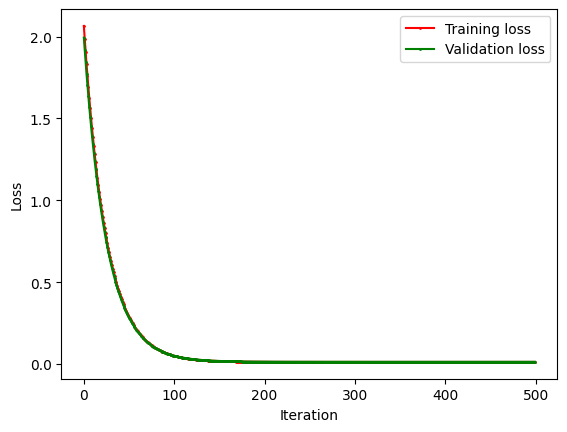

=== Linear Regression Evaluation ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
Built model for linear_data_C with learning rate = 0.001
50. Training loss: 1.7022307356186879, Val loss:1.704399561902757
100. Training loss: 1.398099093422373, Val loss:1.4007211470145513
150. Training loss: 1.1487734111234604, Val loss:1.1516658664027397
200. Training loss: 0.9443693636081101, Val loss:0.9473976449419805
250. Training loss: 0.7767867515803092, Val loss:0.7798533335010577
300. Training loss: 0.6393871949572303, Val loss:0.642422853410673
350. Training loss: 0.5267301015086948, Val loss:0.5296870971374619
400. Training loss: 0.4343563650291918, Val loss:0.43720314708376423
450. Training loss: 0.3586111574044348, Val loss:0.3613282625111078
500. Training loss: 0.29649874274023047, Val loss:0.299075630842221


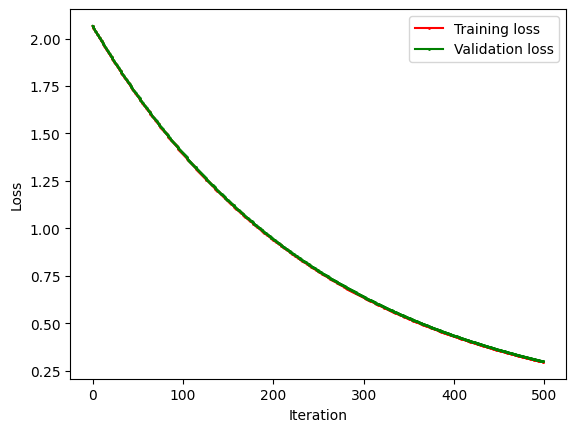

=== Linear Regression Evaluation ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994
Using dataset: linear_data_D
X size: (8000, 6), y size: (8000,)
Processing linear_data_D: size=8000, dim=5
Built model for linear_data_D with learning rate = 0.1
50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


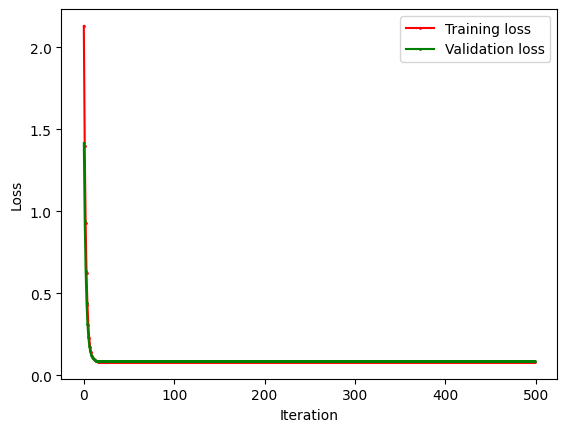

=== Linear Regression Evaluation ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
Built model for linear_data_D with learning rate = 0.01
50. Training loss: 0.37036434877220487, Val loss:0.368684956398332
100. Training loss: 0.12143459698593069, Val loss:0.12553859557797448
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594523, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529508
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416795


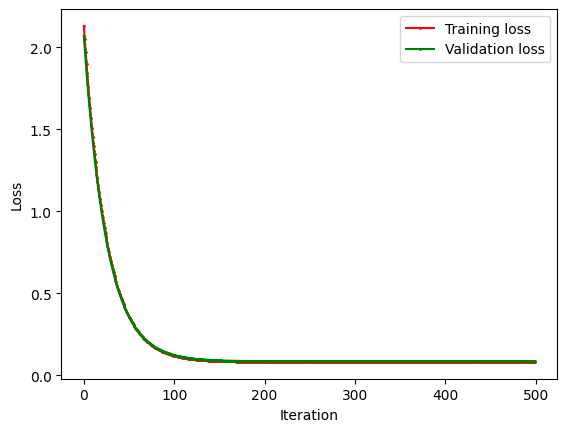

=== Linear Regression Evaluation ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
Built model for linear_data_D with learning rate = 0.001
50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.4648524964143852, Val loss:1.4770554865390984
150. Training loss: 1.2159645145907354, Val loss:1.2278106296911493
200. Training loss: 1.0119199428934709, Val loss:1.0233353741451867
250. Training loss: 0.8446325767970523, Val loss:0.8555746535033423
300. Training loss: 0.7074755244845352, Val loss:0.71792454665939
350. Training loss: 0.5950176249327077, Val loss:0.6049705693586137
400. Training loss: 0.5028075148402399, Val loss:0.5122732093945561
450. Training loss: 0.4271967232656893, Val loss:0.4361921692270864
500. Training loss: 0.3651947340371162, Val loss:0.3737423235472047


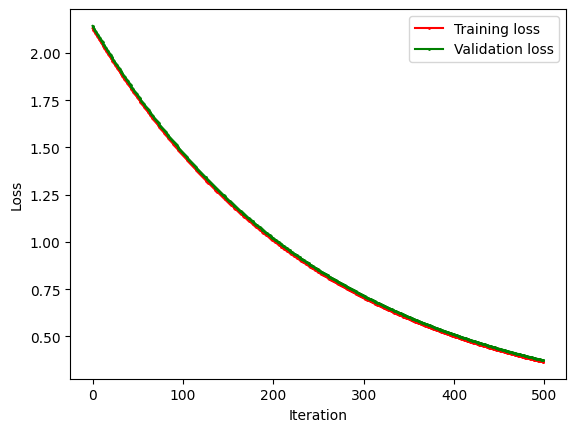

=== Linear Regression Evaluation ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


In [10]:
datasets = ['linear_data_A', 'linear_data_B', 'linear_data_C', 'linear_data_D']
learning_rates = [0.1, 0.01, 0.001]
output_dir = 'results/Q1_3'
os.makedirs(output_dir, exist_ok=True)
run_all_linear_regression(datasets,learning_rates,output_dir)
